# Module 5 — Threat Embeddings for Contextual Linking
**Hands-on Lab (2 Parts):** MiniLM Embeddings → Clustering & Campaign Grouping

This notebook delivers two parts:
1) **Visual embedding clustering plot for anomalies** (UMAP + DBSCAN), using MiniLM embeddings.
2) **Mini-task: Group phishing incidents by embeddings** (cosine similarity graph).

> HDBSCAN is **not** required (and not used). We rely on **DBSCAN** and a simple **graph thresholding** approach.


## Environment Setup

**Recommended Python:** 3.9–3.11

Install dependencies (CPU-only is fine):
```bash
pip install --upgrade pip
pip install "sentence-transformers>=3.0.0" torch --extra-index-url https://download.pytorch.org/whl/cpu
pip install pandas numpy scikit-learn umap-learn matplotlib
```
> If you already have these installed, you can skip.


## 1) Load a publicly available phishing dataset

Prepared Phishing dataset is in the Github repository. You can use it "phishingDS.csv" or you can download publicly available dataset. 

Expected columns:
- `subject`
- `body`


In [1]:

import pandas as pd, io, textwrap, os, sys

LOCAL_CSV = os.path.abspath(r".\phishingDS.csv")

df_raw = None
used_url = None

# Try local CSV first (explicit path). This ensures the notebook uses the local dataset
# you requested rather than attempting remote downloads.
if os.path.exists(LOCAL_CSV):
    try:
        df_raw = pd.read_csv(LOCAL_CSV)
        used_url = LOCAL_CSV
        print(f"Loaded local dataset from: {LOCAL_CSV}  shape={df_raw.shape}")
    except Exception as e:
        print(f"Failed to read local CSV {LOCAL_CSV}: {e}")
        df_raw = None
        used_url = None
else:
    print(f"Local file not found at: {LOCAL_CSV}")

# If local load failed, fall back to the embedded sample so the lab remains runnable.
if df_raw is None or not set(df_raw.columns).intersection({"subject","body"}):
    print("Falling back to embedded sample dataset...")
    sample_rows = [
        {"subject":"Verify your Office365 account urgently","body":"We noticed unusual sign-in activity. Please verify your credentials to avoid suspension."},
        {"subject":"Your mailbox storage is full","body":"Click here to increase your mailbox quota, or messages will be delayed."},
        {"subject":"Password Expiration Notice","body":"Your password expires today. Reset now to maintain access."},
        {"subject":"DHL parcel awaiting delivery confirmation","body":"Your package is pending. Please pay the small customs fee to release it."},
        {"subject":"Payroll update required","body":"We could not process your salary. Update your bank info immediately."},
        {"subject":"Security alert: New sign-in to your account","body":"We detected a new login from an unknown device. Review activity."},
        {"subject":"Internal: Q3 meeting moved","body":"Genuine internal note about rescheduling the Q3 meeting."},
        {"subject":"Weekly lunch menu","body":"This week’s menu includes vegetarian options for the team cafeteria."},
        {"subject":"VPN maintenance window","body":"Planned maintenance on VPN gateway; short downtime expected."},
        {"subject":"GitHub: New PR assigned","body":"A pull request has been assigned to you. Please review."},
    ]
    df_raw = pd.DataFrame(sample_rows)
    used_url = "embedded_fallback"

# Minimal schema normalization and safety checks
needed = ["subject","body"]
missing = [c for c in needed if c not in df_raw.columns]
assert not missing, f"Missing required columns: {missing}"

df = df_raw.copy()
df["text"] = (df["subject"].fillna("") + " " + df["body"].fillna("")).str.strip()
df = df[df["text"].str.len() > 0].reset_index(drop=True)

print("Final dataset shape:", df.shape)
print("Data source:", used_url)
df.head(5)


Loaded local dataset from: c:\Users\emrec\Downloads\phishingDS.csv  shape=(39154, 7)
Final dataset shape: (39154, 8)
Data source: c:\Users\emrec\Downloads\phishingDS.csv


,sender,receiver,date,subject,body,label,urls,text
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1,"Never agree to be a loser Buck up, your troubl..."
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1,Befriend Jenna Jameson \nUpgrade your sex and ...
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1,CNN.com Daily Top 10 >+=+=+=+=+=+=+=+=+=+=+=+=...
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,0,1,Re: svn commit: r619753 - in /spamassassin/tru...
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,1,SpecialPricesPharmMoreinfo \nWelcomeFastShippi...


---
# Part 1 — Visual Embedding Clustering Plot for Anomalies

**Goal:** Encode emails with **MiniLM** → cluster with **DBSCAN** → reduce to 2D with **UMAP** → **highlight anomalies** (noise points).


In [2]:
# Check kernel interpreter, install tf-keras shim and compatible packages into that interpreter,
# then try importing sentence_transformers to verify.
import sys
print("Kernel Python:", sys.executable)
print("Python version:", sys.version)

# Install the backwards-compatible shim required by transformers
!"{sys.executable}" -m pip install --upgrade pip
!"{sys.executable}" -m pip install --upgrade tf-keras
!"{sys.executable}" -m pip install --upgrade transformers sentence-transformers

# Verify import (may still require a kernel restart in the notebook UI)
import importlib, traceback
for pkg in ("tf_keras", "transformers", "sentence_transformers"):
    try:
        mod = importlib.import_module(pkg)
        print(f"{pkg} import OK — version:", getattr(mod, "__version__", "n/a"))
    except Exception as e:
        print(f"{pkg} import FAILED:")
        traceback.print_exc()

Kernel Python: f:\anaconda\python.exe
Python version: 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]

tf_keras import OK — version: 2.20.1
transformers import OK — version: 4.57.1
sentence_transformers import OK — version: 5.1.2


In [3]:
# Replace sentence_transformers usage with plain transformers + mean-pooling (works without sentence_transformers package).
# This computes the same MiniLM embeddings (384 dim) and returns normalized numpy vectors.
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np

model_name = "sentence-transformers/all-MiniLM-L6-v2"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)
model.eval()

texts = df["text"].astype(str).tolist()

def embed_texts(texts, batch_size=64, normalize=True):
    out_embs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(batch, padding=True, truncation=True, return_tensors="pt")
        input_ids = enc["input_ids"].to(device)
        attention_mask = enc["attention_mask"].to(device)
        with torch.no_grad():
            out = model(input_ids=input_ids, attention_mask=attention_mask, return_dict=True)
            token_emb = out.last_hidden_state            # shape (B, T, D)
            mask = attention_mask.unsqueeze(-1).expand(token_emb.size()).float()
            summed = torch.sum(token_emb * mask, dim=1) # sum over tokens
            counts = torch.clamp(mask.sum(dim=1), min=1e-9)
            pooled = summed / counts                    # mean pooling
            if normalize:
                pooled = torch.nn.functional.normalize(pooled, p=2, dim=1)
            out_embs.append(pooled.cpu().numpy())
    return np.vstack(out_embs)

emb = embed_texts(texts, batch_size=64, normalize=True)
print("emb shape:", emb.shape)

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

f:\anaconda\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\emrec\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

emb shape: (39154, 384)


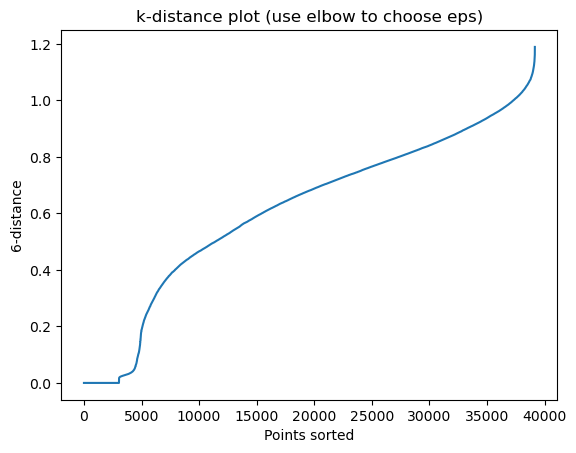

In [4]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

k = 6
nbrs = NearestNeighbors(n_neighbors=k).fit(emb)   # or fit(xy) if clustering UMAP
distances, _ = nbrs.kneighbors(emb)
kdist = np.sort(distances[:, -1])
plt.plot(kdist)
plt.ylabel(f"{k}-distance")
plt.xlabel("Points sorted")
plt.title("k-distance plot (use elbow to choose eps)")
plt.show()

In [5]:
# DBSCAN on original embeddings using euclidean (use eps from k-distance elbow ~0.4)
from sklearn.cluster import DBSCAN
import numpy as np

db = DBSCAN(eps=0.4, min_samples=6, metric="euclidean", n_jobs=-1)
labels = db.fit_predict(emb)
df["cluster"] = labels
df["is_noise"] = (labels == -1).astype(int)
print(df["cluster"].value_counts().sort_index())

cluster
-1      30233
 0        962
 1          8
 2         13
 3         46
        ...  
 240        4
 241       54
 242       17
 243        6
 244        7
Name: count, Length: 246, dtype: int64


In [7]:
# Ensure a 2D projection exists (UMAP preferred, PCA fallback).
import sys
import numpy as np

try:
    from umap import UMAP
    print("Using UMAP for 2D projection")
    umap_2d = UMAP(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=42)
    xy = umap_2d.fit_transform(emb)   # emb must be defined (N, D)
except Exception as e:
    # Fallback to PCA if UMAP not available or fails
    print("UMAP failed or not installed, falling back to PCA:", e)
    from sklearn.decomposition import PCA
    pca = PCA(n_components=2, random_state=42)
    xy = pca.fit_transform(emb)

print("xy shape:", xy.shape)


UMAP failed or not installed, falling back to PCA: No module named 'umap'
xy shape: (39154, 2)


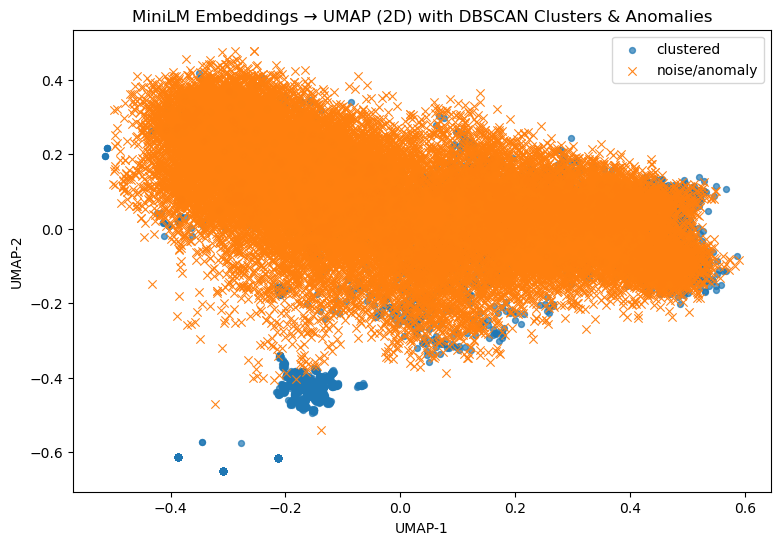

In [8]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(9,6))
noise = df["cluster"] == -1
ax.scatter(xy[~noise,0], xy[~noise,1], s=18, alpha=0.7, label="clustered")
ax.scatter(xy[noise,0], xy[noise,1], s=36, alpha=0.95, label="noise/anomaly", marker="x", linewidth=0.8)
ax.set_title("MiniLM Embeddings → UMAP (2D) with DBSCAN Clusters & Anomalies")
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
ax.legend()
plt.show()


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

mask = df["cluster"] >= 0
texts = df.loc[mask, "text"].tolist()
clusters = df.loc[mask, "cluster"].tolist()

if len(texts) > 0:
    tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1,2), stop_words="english")
    X = tfidf.fit_transform(texts)
    terms = np.array(tfidf.get_feature_names_out())
    cluster_names = {}
    for c in sorted(set(clusters)):
        idx = [i for i,k in enumerate(clusters) if k == c]
        if not idx:
            continue
        mean_tfidf = X[idx].mean(axis=0).A1
        top = terms[mean_tfidf.argsort()[-5:][::-1]]
        cluster_names[c] = ", ".join(top)
    cluster_names
else:
    print("No clustered points to extract terms from.")


---
# Part 2 — Mini-task: Group Phishing Incidents by Embeddings

We’ll form **campaign-like groups** via a **cosine similarity graph**:
- Build pairwise cosine similarity on normalized MiniLM embeddings
- Connect emails with similarity ≥ τ (threshold)
- Extract **connected components** as groups
- Name groups with **top TF-IDF terms** and pick an **exemplar** per group


In [11]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

S = cosine_similarity(emb)
np.fill_diagonal(S, 0.0)

tau = 0.75  # Tune this threshold
edges = np.argwhere(S >= tau)

parent = list(range(len(df)))
def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x
def union(x,y):
    rx, ry = find(x), find(y)
    if rx != ry:
        parent[ry] = rx

for i,j in edges:
    union(int(i), int(j))

comp_id = [find(i) for i in range(len(df))]
id_map = {old:i for i,old in enumerate(sorted(set(comp_id)))}
df["campaign_group"] = [id_map[c] for c in comp_id]
df["campaign_group"].value_counts().sort_index()


campaign_group
0         1
1       962
2         1
3        20
4         7
       ... 
9917      1
9918      1
9919      1
9920      1
9921      1
Name: count, Length: 9922, dtype: int64

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

tfidf = TfidfVectorizer(max_features=4000, ngram_range=(1,2), stop_words="english")
X = tfidf.fit_transform(df["text"])
terms = np.array(tfidf.get_feature_names_out())

group_meta = {}
for g in sorted(df["campaign_group"].unique()):
    idx = df.index[df["campaign_group"] == g].tolist()
    mean_tfidf = X[idx].mean(axis=0).A1
    top = terms[mean_tfidf.argsort()[-6:][::-1]]
    centroid = emb[idx].mean(axis=0, keepdims=True)
    sims = (emb[idx] @ centroid.T).ravel()
    exemplar_i = idx[int(np.argmax(sims))]
    group_meta[g] = {
        "size": len(idx),
        "top_terms": top.tolist(),
        "exemplar_row": int(exemplar_i),
        "exemplar_subject": df.loc[exemplar_i, "subject"] if "subject" in df else ""
    }

group_meta


{0: {'size': 1,
  'top_terms': ['caused', 'agree', 'soon', 'small', 'woman', 'come'],
  'exemplar_row': 0,
  'exemplar_subject': 'Never agree to be a loser'},
 1: {'size': 962,
  'top_terms': ['cnn', 'cnn com', 'www cnn', '08 01', 'video', 'index html'],
  'exemplar_row': 2,
  'exemplar_subject': 'CNN.com Daily Top 10'},
 2: {'size': 1,
  'top_terms': ['en', 'zvllln eum', 'enterprise', 'error', 'eric', 'er'],
  'exemplar_row': 5,
  'exemplar_subject': 'From Caroline Aragon'},
 3: {'size': 20,
  'top_terms': ['visit', 'credit', 'payment', 'term', 'apply', 'card'],
  'exemplar_row': 24335,
  'exemplar_subject': 'debt managment'},
 4: {'size': 7,
  'top_terms': ['production',
   'adobe',
   'rich',
   'professional',
   'collection',
   'suite'],
  'exemplar_row': 31620,
  'exemplar_subject': 'Adobe Contribute CS3'},
 5: {'size': 14,
  'top_terms': ['month', 'increase', 'plus', 'notice', 'width', 'size'],
  'exemplar_row': 21736,
  'exemplar_subject': 'Fifth / Sixth month'},
 6: {'size': 

In [ ]:
out_cols = ["subject","body","cluster","is_noise","campaign_group"]
df_out = df.copy()
for c in out_cols:
    if c not in df_out.columns:
        df_out[c] = ""
df_out[out_cols].to_csv("embeddings_groups_output.csv", index=False)
"Saved embeddings_groups_output.csv"


'Saved embeddings_groups_output.csv'

---
## Notes

- **Why embeddings?** They capture **semantic similarity** beyond keyword overlap.
- **Anomalies:** DBSCAN label `-1` highlights outliers (semantically unusual emails).
- **Campaign grouping:** Adjust **τ** to change granularity; demonstrate split/merge behavior.
- **Explainability:** Use **top TF-IDF terms** to name clusters.
- **Next step:** Attach per-group enrichment (IOCs, ATT&CK mapping) and push to case management.
